<a href="https://colab.research.google.com/github/rongxie2023/dlcv/blob/main/Chapter04/01-Issues_with_image_translation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from torchvision import datasets

import torchvision.transforms as transforms 

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [2]:
data_folder = '../data/FMNIST' # This can be any directory you want to download FMNIST to

transform = transforms.Compose([
    transforms.ToTensor()   #这个函数会将数据归一化
])

def get_data(): 
    train_dataset = datasets.FashionMNIST(root=data_folder, train=True, transform=transform, download=True)
    test_dataset = datasets.FashionMNIST(root=data_folder, train=False, transform=transform, download=True)
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)
    return train_loader,test_loader


In [3]:

from torch.optim import SGD, Adam
def get_model():
    model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=1e-3)
    return model, loss_fn, optimizer

def train_batch(x, y, model, opt, loss_fn):
    prediction = model(x)
    batch_loss = loss_fn(prediction, y)
    batch_loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    return batch_loss.item()

def accuracy(x, y, model):
    with torch.no_grad():
        prediction = model(x)
    max_values, argmaxes = prediction.max(-1)
    is_correct = argmaxes == y
    return is_correct.cpu().numpy().tolist()


In [4]:
def val_loss(x, y, model):
    with torch.no_grad():
        prediction = model(x)
    val_loss = loss_fn(prediction, y)
    return val_loss.item()

In [5]:
trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()

In [7]:
train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []
for epoch in range(5):
    print(epoch)
    train_epoch_losses, train_epoch_accuracies = [], []
    for x,y in trn_dl:
        x=x.to(device)
        y=y.to(device)
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)        
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)
    train_epoch_loss = np.array(train_epoch_losses).mean()
    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    for x,y  in val_dl:
        x=x.to(device)
        y=y.to(device)
        val_is_correct = accuracy(x, y, model)
        validation_loss = val_loss(x, y, model)
    val_epoch_accuracy = np.mean(val_is_correct)

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)
    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)

0
1
2
3
4


In [9]:
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)
tr_images = fmnist.data
tr_targets = fmnist.targets


Text(0.5, 1.0, 'Trouser')

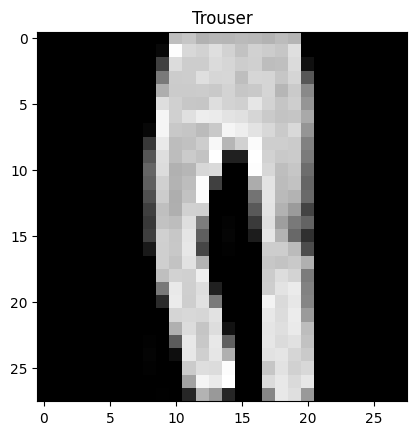

In [10]:

#ix = np.random.randint(len(tr_images))
ix = 24300
plt.imshow(tr_images[ix], cmap='gray')
plt.title(fmnist.classes[tr_targets[ix]])

In [17]:
img = tr_images[ix]/255.
img = img.view((1,28,28))
img = img.to(device)
print(img)

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.7451, 0.7765, 0.6980, 0.7176, 0.7137, 0.7294,
          0.7216, 0.7059, 0.7373, 0.7098, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0314, 0.9922, 0.8471, 0.8235, 0.8745, 0.8235, 0.7608,
          0.8196, 0.8000, 0.7765, 0.8745, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.2510, 0.8627, 0.8039, 0.8039, 0.8588, 0.8392, 0.8039,
          0.8157, 0.7412, 0.7490, 0.8588, 0.0627, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.4784, 0.8000, 0.8039, 0.8745, 0.8392, 0.8431, 0.7451,
          0.8392, 0.8353, 0.7765, 0.8353, 0.3412, 0.0000,

In [18]:
np_output = model(img).cpu().detach().numpy()
np.exp(np_output)/np.sum(np.exp(np_output))

array([[8.8161578e-06, 9.9998826e-01, 2.8642338e-08, 1.8980830e-06,
        5.5994004e-08, 5.9579133e-11, 9.1756715e-07, 2.8866889e-18,
        9.3026592e-10, 2.3268369e-13]], dtype=float32)

Translation

In [19]:
tr_targets[ix]

tensor(1)

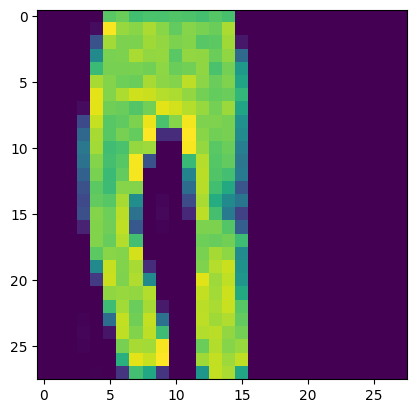

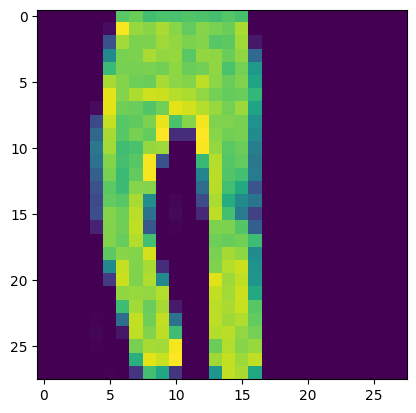

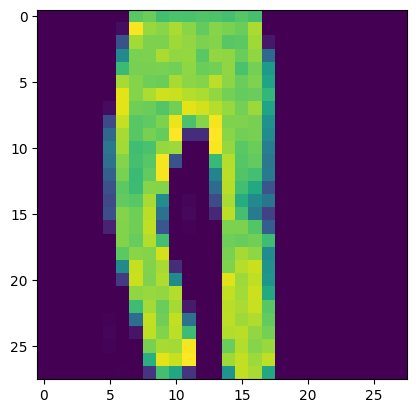

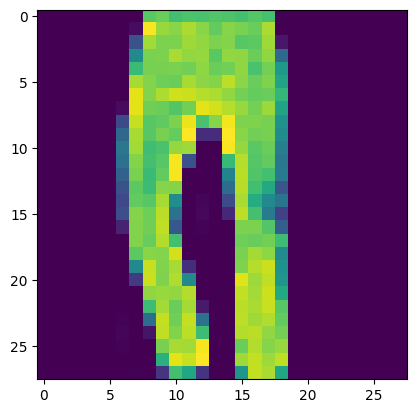

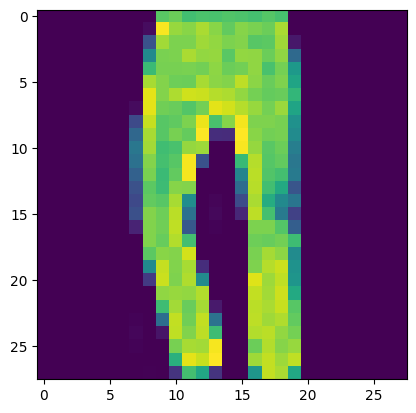

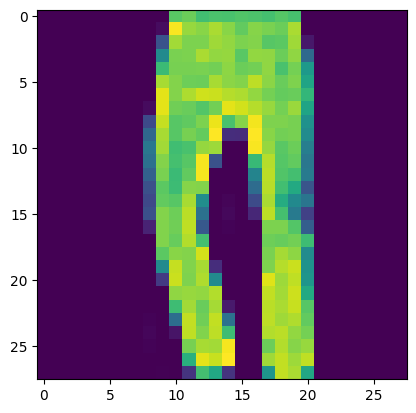

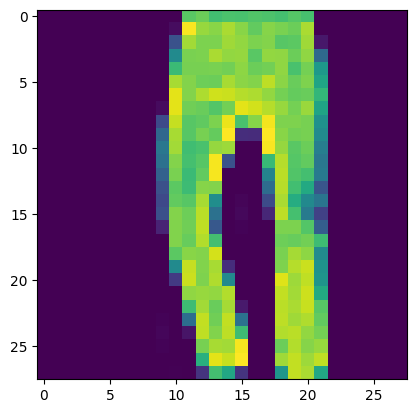

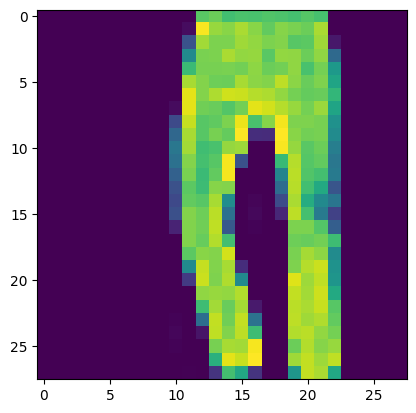

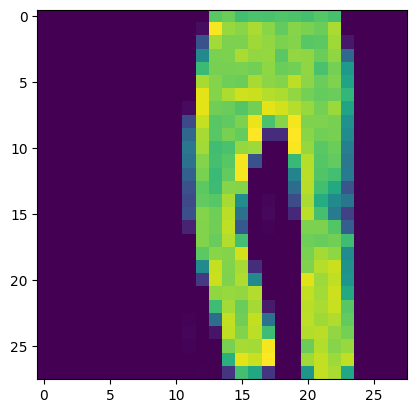

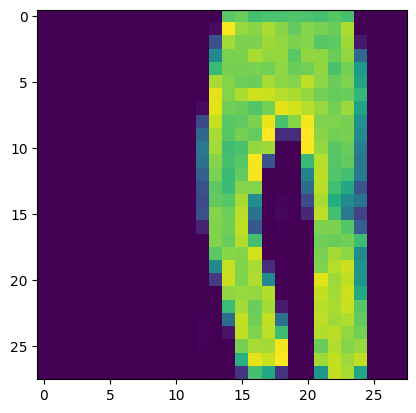

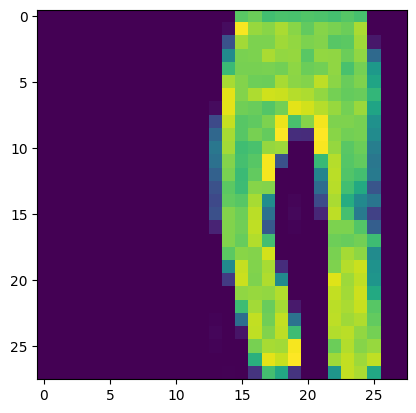

In [33]:
preds = []
for px in range(-5,6):
  img = tr_images[ix]/255.
  img2 = np.roll(img, px, axis=1)
  plt.imshow(img2)
  plt.show()
  img3 = torch.Tensor(img2).view((1,28,28)).to(device)
  np_output = model(img3).cpu().detach().numpy()
  pred=np.exp(np_output)/np.sum(np.exp(np_output))
  pred=pred.squeeze(0)
  preds.append(pred)

<Axes: title={'center': 'Probability of each class for various translations'}>

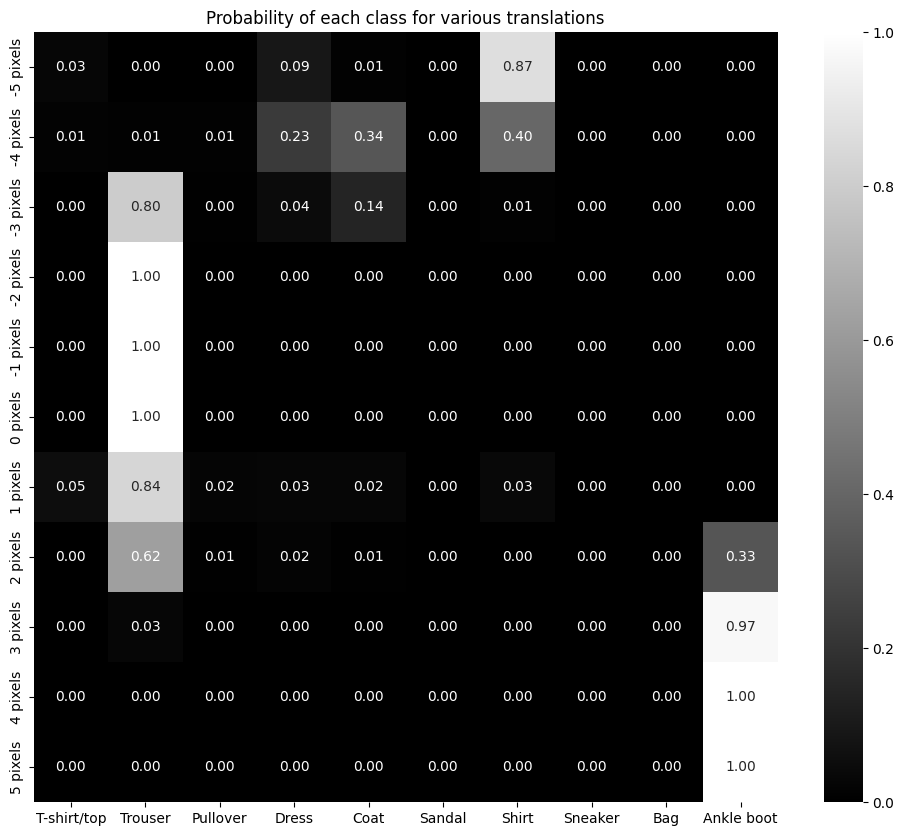

In [35]:
import seaborn as sns
fig, ax = plt.subplots(1,1, figsize=(12,10))
plt.title('Probability of each class for various translations')
sns.heatmap(np.array(preds), annot=True, ax=ax, fmt='.2f', xticklabels=fmnist.classes, yticklabels=[str(i)+str(' pixels') for i in range(-5,6)], cmap='gray')